# AI for Finance — TP: Trading with Reinforcement Learning

**Asset:** BTC-USD &nbsp;|&nbsp; **Period:** 2019–2024 &nbsp;|&nbsp; **Split:** 70% train / 30% test

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, random, copy
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from scipy import stats
import yfinance as yf

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

---
## Section 1 — The Trading Environment

We build a single-asset environment in the OpenAI Gym style.

**State** $s_t \in \mathbb{R}^{W+2}$: $W$ z-scored log-returns + current position $q_t \in \{-1,0,+1\}$ + normalised unrealised PnL.

**Actions** $a_t \in \{0,1,2\}$ = hold / buy / sell.

**Reward** $r_t = q_t(p_{t+1}-p_t) - c \cdot \mathbf{1}[q_{t+1}\neq q_t]$ where $c = 0.001 \times p_t$.

In [2]:
def download_data(ticker='BTC-USD', start='2019-01-01', end='2024-12-31'):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if df.empty:
        raise RuntimeError(f'No data for {ticker}. Check connection and retry.')
    df = df[['Close']].rename(columns={'Close': 'price'})
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['price'] = df['price'].squeeze()
    df['log_return'] = np.log(df['price'] / df['price'].shift(1))
    df = df.dropna().copy()
    print(f'Downloaded {len(df)} days for {ticker} ({df.index[0].date()} -> {df.index[-1].date()})')
    return df


class TradingEnv:
    HOLD, BUY, SELL = 0, 1, 2

    def __init__(self, prices, window=20, cost=0.001):
        self.prices      = np.array(prices, dtype=np.float64).ravel()
        self.window      = window
        self.cost        = cost
        self.n_steps     = len(prices)
        self.log_returns = np.zeros(self.n_steps)
        self.log_returns[1:] = np.log(self.prices[1:] / self.prices[:-1])
        self.state_dim   = window + 2
        self.action_dim  = 3

    def _zscore(self, t):
        w  = self.log_returns[t - self.window + 1: t + 1]
        return (w - w.mean()) / (w.std() + 1e-8)

    def _upnl(self):
        if self.position == 0 or self.entry_price is None:
            return 0.0
        return self.position * (self.prices[self.t] - self.entry_price) / self.prices[self.t]

    def _state(self):
        return np.append(self._zscore(self.t), [float(self.position), self._upnl()])

    def reset(self):
        self.t           = self.window - 1
        self.position    = 0
        self.entry_price = None
        return self._state()

    def step(self, action):
        prev_pos = self.position
        p_now    = self.prices[self.t]

        if self.position == 0:
            if action == self.BUY:  self.position = +1; self.entry_price = p_now
            elif action == self.SELL: self.position = -1; self.entry_price = p_now
        elif self.position == +1:
            if action == self.SELL: self.position = 0; self.entry_price = None
        elif self.position == -1:
            if action == self.BUY:  self.position = 0; self.entry_price = None

        p_next = self.prices[self.t + 1] if self.t + 1 < self.n_steps else p_now
        tc     = self.cost * p_now if self.position != prev_pos else 0.0
        reward = prev_pos * (p_next - p_now) - tc

        self.t += 1
        done       = self.t >= self.n_steps - 1
        next_state = self._state() if not done else np.zeros(self.state_dim)
        return next_state, reward, done, {'position': self.position, 'price': p_now, 'prev_pos': prev_pos}


def split_data(prices, train_ratio=0.70):
    split = int(len(prices) * train_ratio)
    return prices[:split], prices[split:]

Downloaded 2190 days for BTC-USD (2019-01-02 -> 2024-12-30)
Train: 1533 days | Test: 657 days
Random policy — mean reward: $-17962.53  std: $39817.57


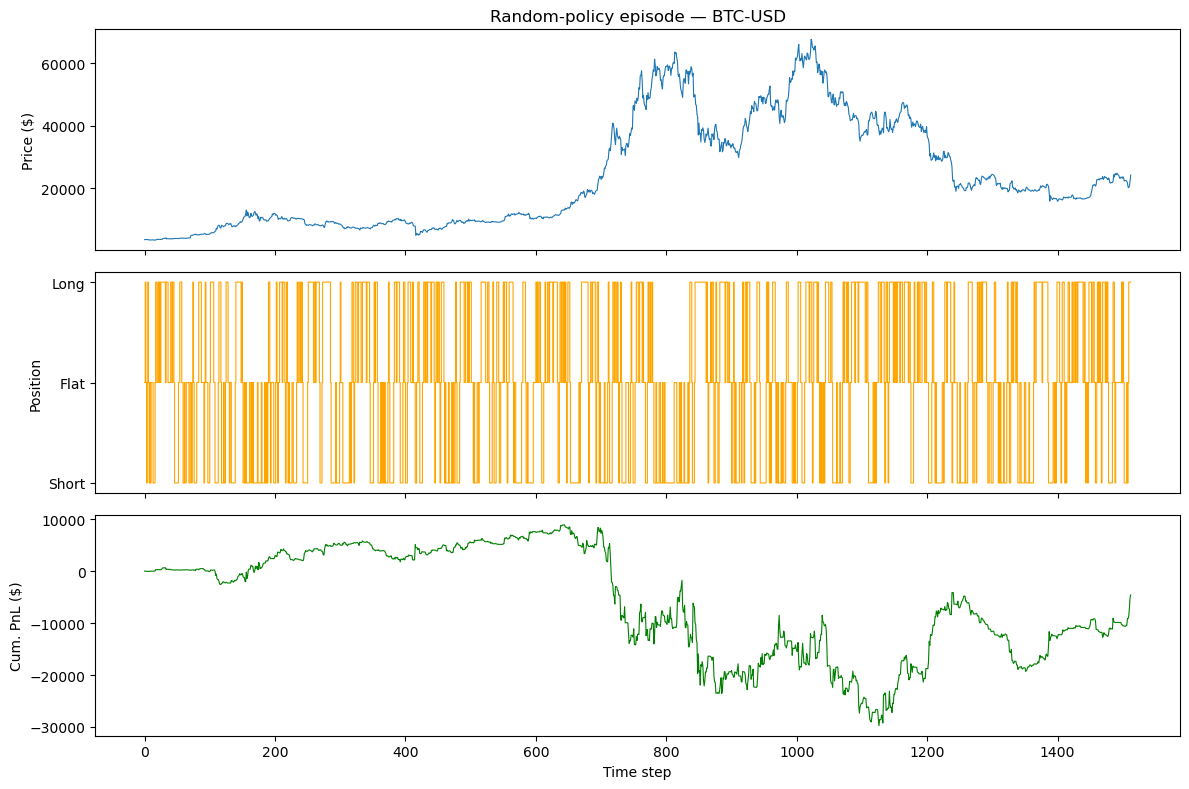

In [3]:
# Download data and run 100 random episodes; plot one
df     = download_data()
prices = df['price'].values
train_prices, test_prices = split_data(prices)
print(f'Train: {len(train_prices)} days | Test: {len(test_prices)} days')

env = TradingEnv(train_prices)

# 100 random episodes
ep_rewards = []
for _ in range(100):
    s, total, done = env.reset(), 0.0, False
    while not done:
        s, r, done, _ = env.step(np.random.randint(3))
        total += r
    ep_rewards.append(total)
print(f'Random policy — mean reward: ${np.mean(ep_rewards):.2f}  std: ${np.std(ep_rewards):.2f}')

# Plot one episode
s, done = env.reset(), False
p_list, pos_list, pnl_list, total = [], [], [], 0.0
while not done:
    s, r, done, info = env.step(np.random.randint(3))
    p_list.append(info['price']); pos_list.append(info['prev_pos'])
    total += r; pnl_list.append(total)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(p_list, lw=0.8); axes[0].set_ylabel('Price ($)'); axes[0].set_title('Random-policy episode — BTC-USD')
axes[1].step(range(len(pos_list)), pos_list, where='post', lw=0.8, color='orange')
axes[1].set_ylabel('Position'); axes[1].set_yticks([-1,0,1]); axes[1].set_yticklabels(['Short','Flat','Long'])
axes[2].plot(pnl_list, lw=0.8, color='green'); axes[2].set_ylabel('Cum. PnL ($)'); axes[2].set_xlabel('Time step')
plt.tight_layout(); plt.savefig('random_episode.png', dpi=150); plt.show()

---
## Section 2 — Q-Learning (Tabular)

We discretise the state to 3 binary features: sign of the 5-day return, sign of the 20-day return, and the current position $q_t$. This gives $2 \times 2 \times 3 = 12$ states and a $12 \times 3$ Q-table.

Update rule: $Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha\left[r_t + \gamma \max_{a'} Q(s_{t+1},a') - Q(s_t,a_t)\right]$

Parameters: $\alpha=0.1$, $\gamma=0.99$, $\varepsilon$ decays from 1.0 to 0.01 over 500 episodes.

In [4]:
def discretize(prices, t, position):
    if t < 20:
        return 6 + {-1:0, 0:1, 1:2}[position]
    s0 = 1 if prices[t] > prices[t-5]  else 0
    s1 = 1 if prices[t] > prices[t-20] else 0
    s2 = {-1:0, 0:1, 1:2}[position]
    return s0*6 + s1*3 + s2


def train_q_learning(train_prices, n_episodes=500, alpha=0.1, gamma=0.99, window=20, cost=0.001):
    Q   = np.zeros((12, 3))
    env = TradingEnv(train_prices, window=window, cost=cost)
    rewards = []
    for ep in range(n_episodes):
        eps = 1.0 - (1.0 - 0.01) * ep / (n_episodes - 1)
        env.reset(); total, done = 0.0, False
        while not done:
            t, pos = env.t, env.position
            s = discretize(env.prices, t, pos)
            a = np.random.randint(3) if np.random.rand() < eps else int(np.argmax(Q[s]))
            _, r, done, _ = env.step(a)
            s2 = discretize(env.prices, env.t, env.position)
            Q[s, a] += alpha * (r + gamma * np.max(Q[s2]) * (1-done) - Q[s, a])
            total += r
        rewards.append(total)
        if (ep+1) % 100 == 0:
            print(f'  Ep {ep+1:4d} | eps={eps:.3f} | reward={total:.2f} | avg50={np.mean(rewards[-50:]):.2f}')
    return Q, rewards


print('Training Q-learning (500 episodes)…')
Q, ql_rewards = train_q_learning(train_prices)

Training Q-learning (500 episodes)…
  Ep  100 | eps=0.804 | reward=-84931.33 | avg50=-12068.40
  Ep  200 | eps=0.605 | reward=-7632.79 | avg50=-15840.92
  Ep  300 | eps=0.407 | reward=18156.70 | avg50=-8092.84
  Ep  400 | eps=0.208 | reward=25168.79 | avg50=-12818.12
  Ep  500 | eps=0.010 | reward=-6366.69 | avg50=-5443.06


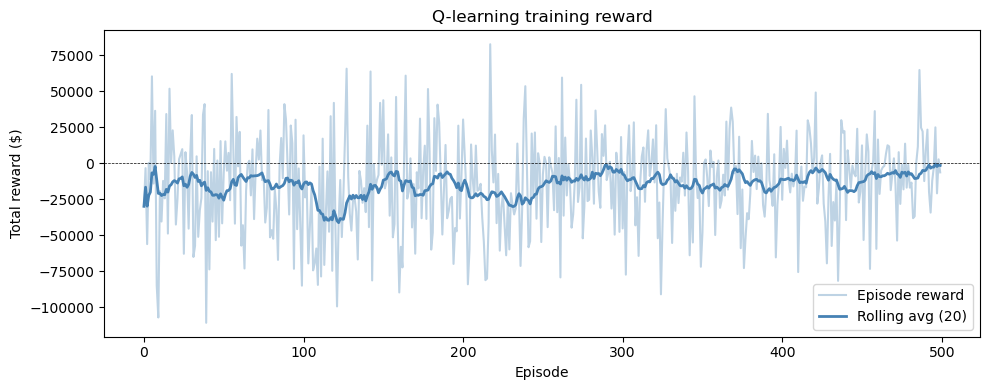

In [5]:
# Training curve
rolling = pd.Series(ql_rewards).rolling(20, min_periods=1).mean()
plt.figure(figsize=(10,4))
plt.plot(ql_rewards, alpha=0.35, color='steelblue', label='Episode reward')
plt.plot(rolling, color='steelblue', lw=2, label='Rolling avg (20)')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.xlabel('Episode'); plt.ylabel('Total reward ($)'); plt.title('Q-learning training reward')
plt.legend(); plt.tight_layout(); plt.savefig('q_learning_training.png', dpi=150); plt.show()


--- Test set results ---
  Q-learning           | return=$      0.00 | Sharpe= 0.000 | MDD=$      0.00 | trades=0
  Buy & Hold           | return=$  68267.25 | Sharpe= 1.135 | MDD=$ -19134.75 | trades=1


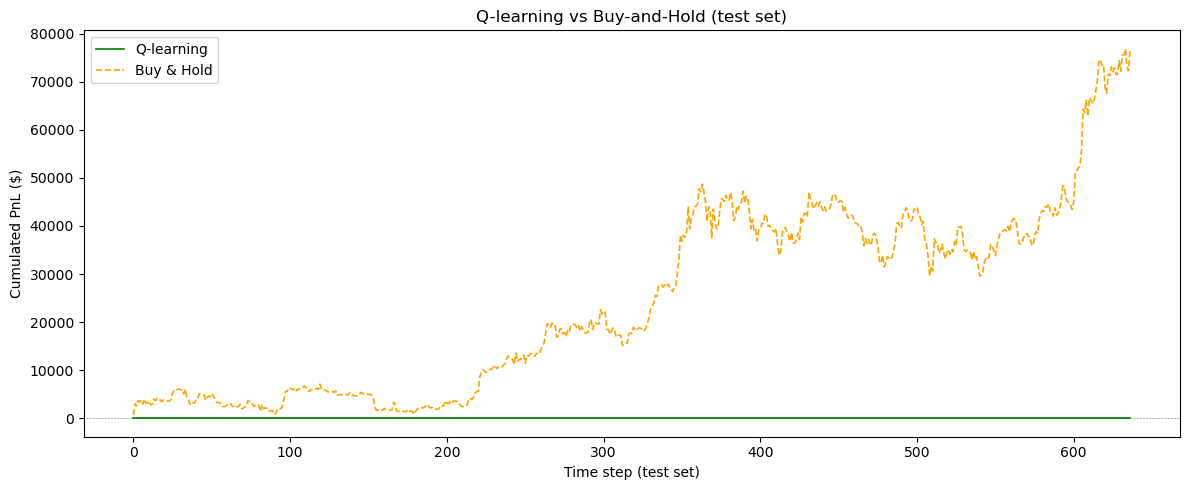

In [6]:
def buy_and_hold(prices):
    return np.cumsum(np.diff(prices))

def compute_metrics(cum_pnl, n_trades, label=''):
    total  = cum_pnl[-1]
    daily  = np.diff(np.insert(cum_pnl, 0, 0.0))
    sharpe = (daily.mean() / (daily.std() + 1e-8)) * np.sqrt(252)
    mdd    = (cum_pnl - np.maximum.accumulate(cum_pnl)).min()
    print(f'  {label:20s} | return=${total:>10.2f} | Sharpe={sharpe:>6.3f} | MDD=${mdd:>10.2f} | trades={n_trades}')
    return dict(total_return=total, sharpe=sharpe, mdd=mdd, n_trades=n_trades)

def eval_q(prices, Q, window=20, cost=0.001):
    env = TradingEnv(prices, window=window, cost=cost)
    env.reset(); cum, total, n_trades, done = [], 0.0, 0, False
    while not done:
        s    = discretize(env.prices, env.t, env.position)
        prev = env.position
        _, r, done, _ = env.step(int(np.argmax(Q[s])))
        total += r; cum.append(total)
        if env.position != prev: n_trades += 1
    return np.array(cum), n_trades

ql_pnl, ql_trades = eval_q(test_prices, Q)
bnh_pnl           = buy_and_hold(test_prices)

print('\n--- Test set results ---')
compute_metrics(ql_pnl,  ql_trades, 'Q-learning')
bnh_daily  = np.diff(np.insert(bnh_pnl, 0, 0.0))
bnh_sharpe = (bnh_daily.mean()/(bnh_daily.std()+1e-8))*np.sqrt(252)
bnh_mdd    = (bnh_pnl - np.maximum.accumulate(bnh_pnl)).min()
print(f'  {"Buy & Hold":20s} | return=${bnh_pnl[-1]:>10.2f} | Sharpe={bnh_sharpe:>6.3f} | MDD=${bnh_mdd:>10.2f} | trades=1')

n = min(len(ql_pnl), len(bnh_pnl))
plt.figure(figsize=(12,5))
plt.plot(ql_pnl[:n],  label='Q-learning', lw=1.2, color='green')
plt.plot(bnh_pnl[:n], label='Buy & Hold', lw=1.2, ls='--', color='orange')
plt.axhline(0, color='black', lw=0.4, ls=':')
plt.xlabel('Time step (test set)'); plt.ylabel('Cumulated PnL ($)')
plt.title('Q-learning vs Buy-and-Hold (test set)'); plt.legend()
plt.tight_layout(); plt.savefig('q_eval.png', dpi=150); plt.show()

In [7]:
# Print Q-table
sign_lbl = ['neg/flat','positive']; pos_lbl = ['Short(-1)','Flat(0)','Long(+1)']; act_lbl = ['Hold','Buy','Sell']
print(f"{'State':>45s} | {'Hold':>8s} | {'Buy':>8s} | {'Sell':>8s} | Best")
print('─'*85)
for s0 in range(2):
    for s1 in range(2):
        for s2 in range(3):
            idx   = s0*6 + s1*3 + s2
            label = f'5d={sign_lbl[s0]}, 20d={sign_lbl[s1]}, pos={pos_lbl[s2]}'
            best  = act_lbl[int(np.argmax(Q[idx]))]
            print(f'  [{idx:2d}] {label:>42s} | {Q[idx,0]:>8.3f} | {Q[idx,1]:>8.3f} | {Q[idx,2]:>8.3f} | {best}')

                                        State |     Hold |      Buy |     Sell | Best
─────────────────────────────────────────────────────────────────────────────────────
  [ 0]   5d=neg/flat, 20d=neg/flat, pos=Short(-1) | -225.512 | -114.892 | 1315.559 | Sell
  [ 1]     5d=neg/flat, 20d=neg/flat, pos=Flat(0) |  788.177 |  773.481 |  715.510 | Hold
  [ 2]    5d=neg/flat, 20d=neg/flat, pos=Long(+1) |  589.567 |  -40.069 |  -11.056 | Hold
  [ 3]   5d=neg/flat, 20d=positive, pos=Short(-1) |  365.152 |  294.271 |  288.224 | Hold
  [ 4]     5d=neg/flat, 20d=positive, pos=Flat(0) |  803.987 |  776.691 |  791.773 | Hold
  [ 5]    5d=neg/flat, 20d=positive, pos=Long(+1) |  573.389 |  544.766 |  869.889 | Sell
  [ 6]   5d=positive, 20d=neg/flat, pos=Short(-1) |  336.738 |  554.365 |  990.474 | Sell
  [ 7]     5d=positive, 20d=neg/flat, pos=Flat(0) |  717.031 |  680.657 |  716.381 | Hold
  [ 8]    5d=positive, 20d=neg/flat, pos=Long(+1) |  154.993 |  169.818 |  138.402 | Buy
  [ 9]   5d=positiv

---
## Section 3 — Deep Q-Network (DQN)

We use the full continuous state (no discretisation). Three key components:

1. **Q-Network** — MLP(W+2 → 64 → 64 → 3) approximates $Q(s,a)$ for all actions.
2. **Experience Replay** — stores transitions $(s,a,r,s',\text{done})$; random mini-batches break temporal correlations.
3. **Target Network** — a frozen copy of the Q-net, updated every $C=100$ steps, stabilises TD targets.

In [8]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, 64),        nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)
    def push(self, s, a, r, s2, done):
        self.buffer.append((s, a, r, s2, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (torch.FloatTensor(np.array(s)), torch.LongTensor(a),
                torch.FloatTensor(r), torch.FloatTensor(np.array(s2)), torch.FloatTensor(d))
    def __len__(self): return len(self.buffer)


class DQNAgent:
    def __init__(self, state_dim, n_actions=3, lr=1e-3, gamma=0.99,
                 buffer_size=10_000, batch_size=64, target_update=100):
        self.n_actions     = n_actions
        self.gamma         = gamma
        self.batch_size    = batch_size
        self.target_update = target_update
        self.step_count    = 0
        self.q_net         = QNetwork(state_dim, n_actions)
        self.target_net    = QNetwork(state_dim, n_actions)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        self.optimizer     = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer        = ReplayBuffer(buffer_size)

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randint(0, self.n_actions - 1)
        with torch.no_grad():
            return int(self.q_net(torch.FloatTensor(state).unsqueeze(0)).argmax().item())

    def update(self):
        if len(self.buffer) < self.batch_size: return
        s, a, r, s2, d = self.buffer.sample(self.batch_size)
        q  = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            tq = r + self.gamma * self.target_net(s2).max(1).values * (1 - d)
        loss = nn.MSELoss()(q, tq)
        self.optimizer.zero_grad(); loss.backward(); self.optimizer.step()
        self.step_count += 1
        if self.step_count % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

In [9]:
def val_reward(agent, prices, window=20, cost=0.001):
    env = TradingEnv(prices, window=window, cost=cost)
    s, total, done = env.reset(), 0.0, False
    agent.q_net.eval()
    with torch.no_grad():
        while not done:
            a = int(agent.q_net(torch.FloatTensor(s).unsqueeze(0)).argmax().item())
            s, r, done, _ = env.step(a); total += r
    agent.q_net.train()
    return total


def train_dqn(train_p, val_p, n_episodes=500, window=20, cost=0.001,
              eps_decay=300, patience=50, val_every=10, reward_lambda=0.0):
    env   = TradingEnv(train_p, window=window, cost=cost)
    agent = DQNAgent(state_dim=env.state_dim)
    best_val, best_w, no_improve = -np.inf, None, 0
    ep_rewards, val_hist = [], []

    for ep in range(n_episodes):
        eps   = 1.0 - (1.0 - 0.01) * min(ep / max(eps_decay-1, 1), 1.0)
        s, total, done = env.reset(), 0.0, False
        while not done:
            a              = agent.select_action(s, eps)
            s2, r, done, _ = env.step(a)
            shaped         = r - reward_lambda * (env.position ** 2)
            agent.buffer.push(s, a, shaped, s2, float(done))
            agent.update()
            s = s2; total += r
        ep_rewards.append(total)

        if (ep+1) % val_every == 0:
            vr = val_reward(agent, val_p, window, cost)
            val_hist.append((ep+1, vr))
            if vr > best_val:
                best_val, best_w, no_improve = vr, copy.deepcopy(agent.q_net.state_dict()), 0
            else:
                no_improve += val_every
            if (ep+1) % 50 == 0:
                print(f'  Ep {ep+1:4d} | eps={eps:.3f} | train={total:.0f} | val={vr:.0f} | best_val={best_val:.0f}')
            if no_improve >= patience:
                print(f'  Early stopping at ep {ep+1} — best val={best_val:.2f}')
                break

    if best_w:
        agent.q_net.load_state_dict(best_w)
        agent.target_net.load_state_dict(best_w)
    return agent, ep_rewards, val_hist


def run_greedy(agent, prices, window=20, cost=0.001):
    env = TradingEnv(prices, window=window, cost=cost)
    s   = env.reset()
    cum_pnl, positions, q_hist = [], [], []
    total, n_trades, done = 0.0, 0, False
    agent.q_net.eval()
    with torch.no_grad():
        while not done:
            qv     = agent.q_net(torch.FloatTensor(s).unsqueeze(0)).squeeze(0).numpy()
            a      = int(np.argmax(qv))
            q_hist.append(qv.copy())
            prev   = env.position
            s, r, done, info = env.step(a)
            total += r; cum_pnl.append(total)
            positions.append(prev)          # q_t: position active during [t, t+1]
            if env.position != prev: n_trades += 1
    agent.q_net.train()
    return np.array(cum_pnl), np.array(positions), np.array(q_hist), n_trades

Training DQN (500 episodes max)…
  Ep   50 | eps=0.838 | train=7488 | val=-11560 | best_val=6624
  Ep  100 | eps=0.672 | train=66491 | val=-1433 | best_val=9075
  Early stopping at ep 110 — best val=9074.66


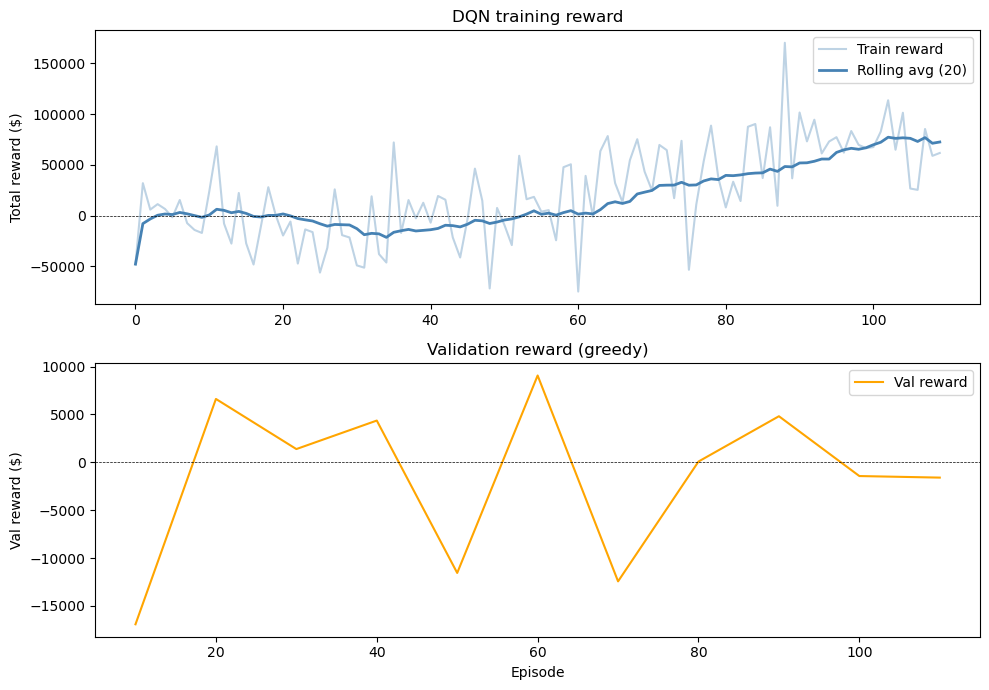

In [10]:
# Train DQN (70% train, last 15% of train used as validation for early stopping)
val_split  = int(len(train_prices) * 0.85)
dqn_train  = train_prices[:val_split]
dqn_val    = train_prices[val_split:]

print('Training DQN (500 episodes max)…')
agent, dqn_ep_rewards, dqn_val_hist = train_dqn(dqn_train, dqn_val, n_episodes=500)

# Training curve
rolling_dqn = pd.Series(dqn_ep_rewards).rolling(20, min_periods=1).mean()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=False)
ax1.plot(dqn_ep_rewards, alpha=0.35, color='steelblue', label='Train reward')
ax1.plot(rolling_dqn, color='steelblue', lw=2, label='Rolling avg (20)')
ax1.axhline(0, color='black', lw=0.5, ls='--'); ax1.set_ylabel('Total reward ($)')
ax1.set_title('DQN training reward'); ax1.legend()
if dqn_val_hist:
    ve, vr = zip(*dqn_val_hist)
    ax2.plot(ve, vr, color='orange', lw=1.5, label='Val reward')
    ax2.axhline(0, color='black', lw=0.5, ls='--')
    ax2.set_xlabel('Episode'); ax2.set_ylabel('Val reward ($)')
    ax2.set_title('Validation reward (greedy)'); ax2.legend()
plt.tight_layout(); plt.savefig('dqn_training.png', dpi=150); plt.show()

--- Test set results ---
  DQN                  | return=$  51059.76 | Sharpe= 0.953 | MDD=$ -18900.41 | trades=313
  Q-learning           | return=$      0.00 | Sharpe= 0.000 | MDD=$      0.00 | trades=0
  Buy & Hold           | return=$  68267.25 | Sharpe= 1.135 | MDD=$ -19134.75 | trades=1


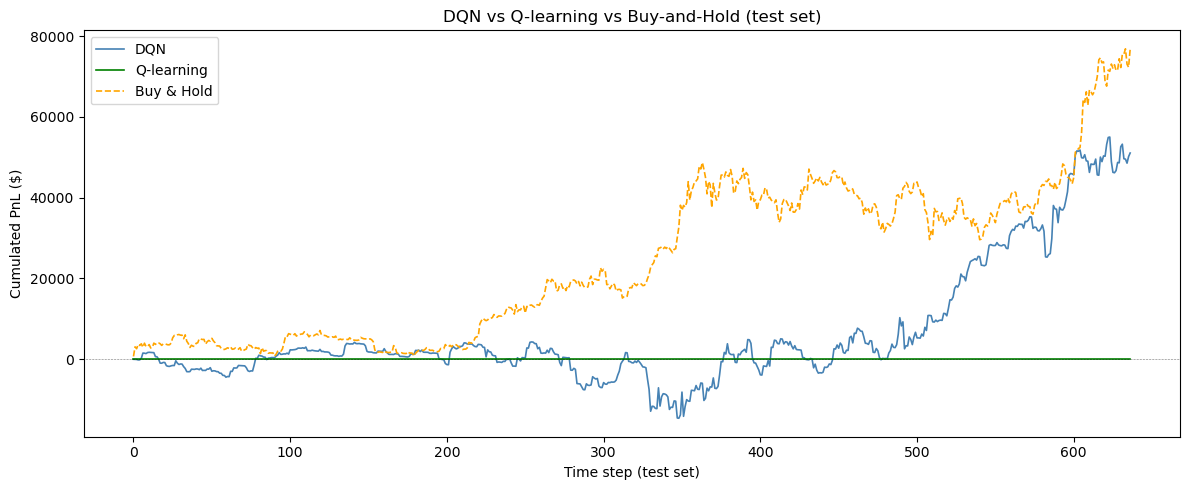

In [11]:
# Evaluate DQN on test set
dqn_pnl, positions, q_hist, dqn_trades = run_greedy(agent, test_prices)

print('--- Test set results ---')
compute_metrics(dqn_pnl, dqn_trades, 'DQN')
compute_metrics(ql_pnl,  ql_trades,  'Q-learning')
print(f'  {"Buy & Hold":20s} | return=${bnh_pnl[-1]:>10.2f} | Sharpe={bnh_sharpe:>6.3f} | MDD=${bnh_mdd:>10.2f} | trades=1')

n = min(len(dqn_pnl), len(bnh_pnl))
plt.figure(figsize=(12,5))
plt.plot(dqn_pnl[:n], label='DQN',        lw=1.2, color='steelblue')
plt.plot(ql_pnl[:n],  label='Q-learning', lw=1.2, color='green')
plt.plot(bnh_pnl[:n], label='Buy & Hold', lw=1.2, ls='--', color='orange')
plt.axhline(0, color='black', lw=0.4, ls=':')
plt.xlabel('Time step (test set)'); plt.ylabel('Cumulated PnL ($)')
plt.title('DQN vs Q-learning vs Buy-and-Hold (test set)'); plt.legend()
plt.tight_layout(); plt.savefig('dqn_eval.png', dpi=150); plt.show()

### 3.6 Ablation Studies

We test the contribution of each DQN component by removing it:
- **(a) No experience replay** — train on sequential transitions instead of random mini-batches
- **(b) No target network** — use the online net for both prediction and TD target
- **(c) Double transaction cost** — test sensitivity to $c$

Running ablations…
  no_replay…
  Ep   50 | eps=0.838 | train=61475 | val=994 | best_val=4407
  Ep  100 | eps=0.672 | train=27883 | val=2654 | best_val=5088
  Early stopping at ep 120 — best val=5088.40
  no_replay            | return=$  44244.56 | Sharpe= 0.773 | MDD=$ -21985.06 | trades=107
  no_target…
  no_target            | return=$   3983.15 | Sharpe= 0.071 | MDD=$ -37546.31 | trades=119
  double_cost…
  Ep   50 | eps=0.838 | train=863 | val=3386 | best_val=4546
  Early stopping at ep 80 — best val=4545.70
  double_cost          | return=$  41025.53 | Sharpe= 0.749 | MDD=$ -17568.33 | trades=159


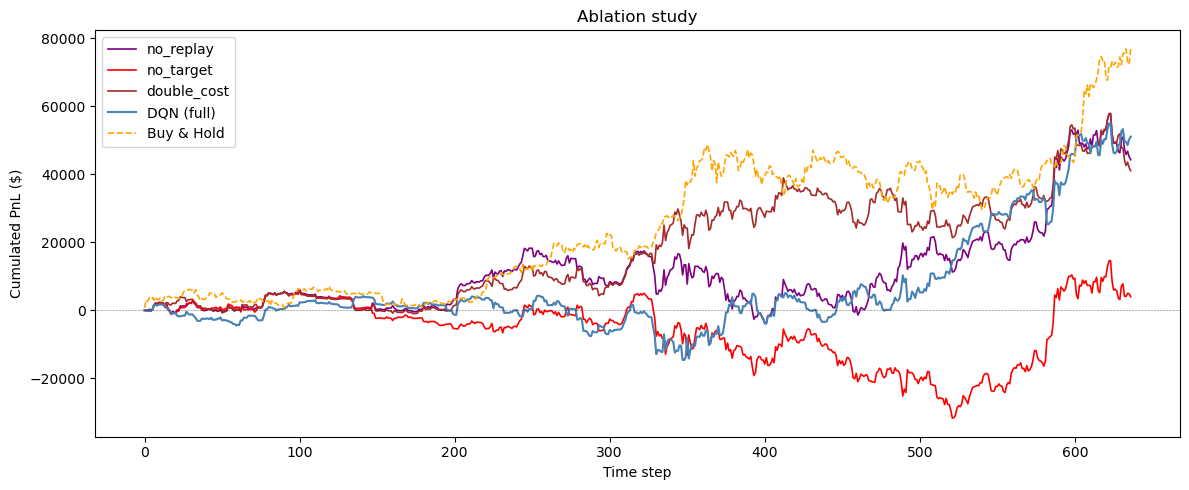

In [12]:
def train_no_replay(train_p, val_p, use_target=True, cost=0.001, n_episodes=500, patience=50, val_every=10):
    """Ablation: train directly on each transition without replay buffer."""
    env   = TradingEnv(train_p, window=20, cost=cost)
    agent = DQNAgent(state_dim=env.state_dim)
    best_val, best_w, no_improve = -np.inf, None, 0
    ep_rewards = []

    for ep in range(n_episodes):
        eps   = 1.0 - (1.0-0.01) * min(ep/max(299,1), 1.0)
        s, total, done = env.reset(), 0.0, False
        while not done:
            a             = agent.select_action(s, eps)
            s2, r, done, _ = env.step(a)
            # Single-step update without replay
            st = torch.FloatTensor(s).unsqueeze(0)
            s2t= torch.FloatTensor(s2).unsqueeze(0)
            qv = agent.q_net(st)[0, a]
            net = agent.target_net if use_target else agent.q_net
            with torch.no_grad():
                tgt = r + agent.gamma * net(s2t).max().item() * (1-float(done))
            loss = nn.MSELoss()(qv, torch.tensor(tgt, dtype=torch.float32))
            agent.optimizer.zero_grad(); loss.backward(); agent.optimizer.step()
            agent.step_count += 1
            if use_target and agent.step_count % agent.target_update == 0:
                agent.target_net.load_state_dict(agent.q_net.state_dict())
            s = s2; total += r
        ep_rewards.append(total)

        if (ep+1) % val_every == 0:
            vr = val_reward(agent, val_p)
            if vr > best_val:
                best_val, best_w, no_improve = vr, copy.deepcopy(agent.q_net.state_dict()), 0
            else:
                no_improve += val_every
            if no_improve >= patience: break

    if best_w: agent.q_net.load_state_dict(best_w); agent.target_net.load_state_dict(best_w)
    return agent, ep_rewards


print('Running ablations…')
ablations = {}
for name, kwargs in [
    ('no_replay',   dict(use_target=True,  cost=0.001)),
    ('no_target',   dict(use_target=False, cost=0.001)),
    ('double_cost', dict(use_target=True,  cost=0.002)),
]:
    print(f'  {name}…')
    if name == 'no_target':
        ag, rw = train_no_replay(dqn_train, dqn_val, **kwargs)
    else:
        ag, rw, _ = train_dqn(dqn_train, dqn_val, n_episodes=500, cost=kwargs['cost'])
    pnl, _, _, nt = run_greedy(ag, test_prices, cost=0.001)
    ablations[name] = pnl
    compute_metrics(pnl, nt, name)

plt.figure(figsize=(12,5))
colors = {'no_replay':'purple','no_target':'red','double_cost':'brown'}
for name, pnl in ablations.items():
    n = min(len(pnl), len(bnh_pnl))
    plt.plot(pnl[:n], label=name, lw=1.2, color=colors[name])
plt.plot(dqn_pnl[:n], label='DQN (full)', lw=1.5, color='steelblue')
plt.plot(bnh_pnl[:n], label='Buy & Hold', lw=1.2, ls='--', color='orange')
plt.axhline(0, color='black', lw=0.4, ls=':')
plt.xlabel('Time step'); plt.ylabel('Cumulated PnL ($)')
plt.title('Ablation study'); plt.legend()
plt.tight_layout(); plt.savefig('dqn_ablations.png', dpi=150); plt.show()

---
## Section 4 — Analysis of the Learned Policy

We examine *what* the agent learned: its action preferences, confidence, and whether its positions predict future returns.

4.1 Action distribution (test set)
   Hold:   51  (8.0%)
    Buy:  299  (46.9%)
   Sell:  287  (45.1%)


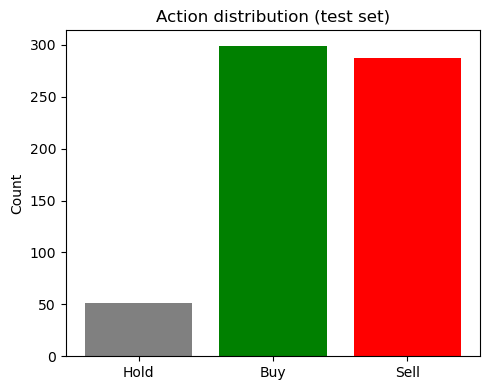

In [13]:
# 4.1 — Action distribution
actions = np.argmax(q_hist, axis=1)
labels  = ['Hold','Buy','Sell']
counts  = [np.sum(actions==i) for i in range(3)]
T       = len(actions)
print('4.1 Action distribution (test set)')
for l, c in zip(labels, counts):
    print(f'  {l:>5s}: {c:4d}  ({100*c/T:.1f}%)')

plt.figure(figsize=(5,4))
plt.bar(labels, counts, color=['grey','green','red'])
plt.ylabel('Count'); plt.title('Action distribution (test set)')
plt.tight_layout(); plt.savefig('dqn_action_dist.png', dpi=150); plt.show()

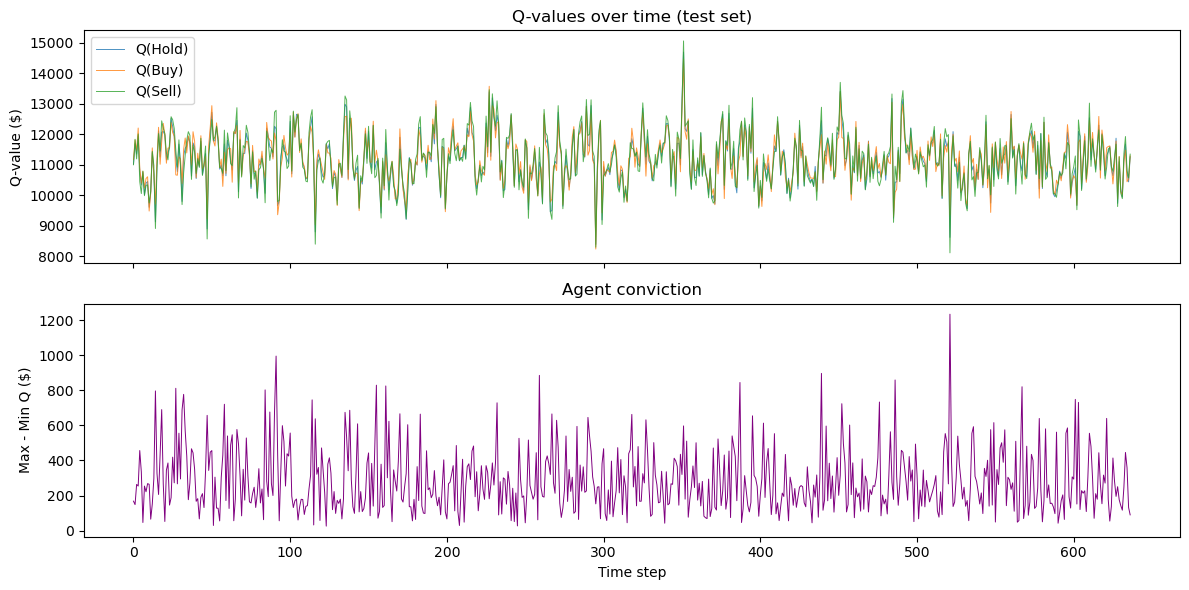

In [14]:
# 4.2 — Q-values over time
gap = q_hist.max(axis=1) - q_hist.min(axis=1)
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(12,6), sharex=True)
for i, l in enumerate(labels):
    ax1.plot(q_hist[:,i], lw=0.7, label=f'Q({l})', alpha=0.8)
ax1.set_ylabel('Q-value ($)'); ax1.set_title('Q-values over time (test set)'); ax1.legend()
ax2.plot(gap, lw=0.7, color='purple')
ax2.set_ylabel('Max - Min Q ($)'); ax2.set_xlabel('Time step'); ax2.set_title('Agent conviction')
plt.tight_layout(); plt.savefig('dqn_q_values.png', dpi=150); plt.show()

In [15]:
# 4.3 — Trend-following vs mean-reverting
window  = 20
t_start = window - 1
ret5    = [(test_prices[t_start+i] - test_prices[t_start+i-5]) / test_prices[t_start+i-5]
           if t_start+i >= 5 else 0.0 for i in range(len(positions))]
ret5    = np.array(ret5)
corr    = np.corrcoef(positions, ret5)[0,1]
direction = 'trend-following' if corr > 0 else 'mean-reverting'
print(f'4.3 Correlation(position, 5-day return) = {corr:.4f}  → {direction}')

# 4.4 — Kendall tau
ndr     = np.diff(test_prices) / test_prices[:-1]
aligned = ndr[t_start: t_start + len(positions)]
n       = min(len(positions), len(aligned))
tau, pv = stats.kendalltau(positions[:n], aligned[:n])
print(f'4.4 Kendall τ = {tau:.4f}   p-value = {pv:.4f}')
if pv < 0.05:
    print('     → Statistically significant at 5%: positions predict next-day returns.')
else:
    print('     → Not statistically significant at 5%.')

4.3 Correlation(position, 5-day return) = 0.2979  → trend-following
4.4 Kendall τ = 0.0568   p-value = 0.0635
     → Not statistically significant at 5%.


---
## Section 5 — Reward Shaping (Bonus)

We replace the reward with a risk-adjusted version:
$$r_t = q_t(p_{t+1}-p_t) - c\,\mathbf{1}[q_{t+1}\neq q_t] - \lambda\,q_t^2$$

The $\lambda q_t^2$ term penalises holding large positions, encouraging the agent to be more selective. We try $\lambda \in \{0.0001, 0.001, 0.01\}$.

Training 3 shaped agents…
         λ |  Return($) |   Sharpe |     MDD($) |  Trades
───────────────────────────────────────────────────────
  Ep   50 | eps=0.838 | train=-500 | val=-6386 | best_val=2190
  Ep  100 | eps=0.672 | train=28961 | val=-5602 | best_val=4235
  Early stopping at ep 130 — best val=4235.27
  λ=0.0001             | return=$  -9229.72 | Sharpe=-0.183 | MDD=$ -29144.16 | trades=253
    0.0001 |   -9229.72 |   -0.183 |  -29144.16 |     253
  Ep   50 | eps=0.838 | train=7696 | val=-6363 | best_val=4070
  Ep  100 | eps=0.672 | train=47792 | val=-3905 | best_val=5303
  Early stopping at ep 120 — best val=5302.81
  λ=0.001              | return=$  -7244.79 | Sharpe=-0.134 | MDD=$ -49798.13 | trades=260
    0.0010 |   -7244.79 |   -0.134 |  -49798.13 |     260
  Ep   50 | eps=0.838 | train=6817 | val=-7386 | best_val=2815
  Early stopping at ep 90 — best val=2815.43
  λ=0.01               | return=$  58730.14 | Sharpe= 1.010 | MDD=$ -14008.31 | trades=39
    0.0100 |   587

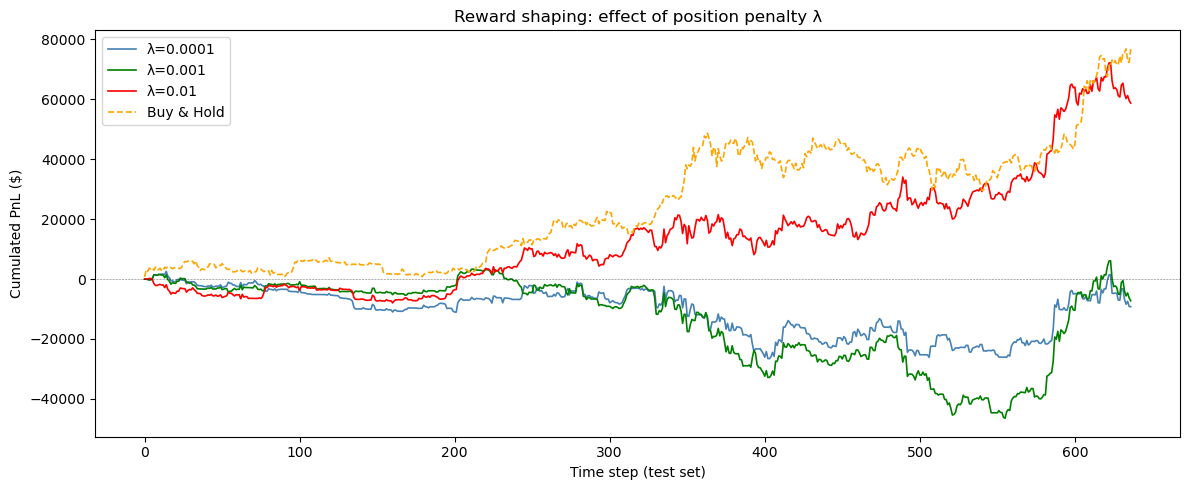

In [16]:
print('Training 3 shaped agents…')
shaped_results = {}
print(f"{'λ':>10s} | {'Return($)':>10s} | {'Sharpe':>8s} | {'MDD($)':>10s} | {'Trades':>7s}")
print('─'*55)

for lam in [0.0001, 0.001, 0.01]:
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    ag, _, _ = train_dqn(dqn_train, dqn_val, n_episodes=500, reward_lambda=lam)
    pnl, _, _, nt = run_greedy(ag, test_prices)
    m = compute_metrics(pnl, nt, f'λ={lam}')
    shaped_results[lam] = pnl
    print(f'{lam:>10.4f} | {m["total_return"]:>10.2f} | {m["sharpe"]:>8.3f} | {m["mdd"]:>10.2f} | {nt:>7d}')

plt.figure(figsize=(12,5))
colors = {0.0001:'steelblue', 0.001:'green', 0.01:'red'}
for lam, pnl in shaped_results.items():
    n = min(len(pnl), len(bnh_pnl))
    plt.plot(pnl[:n], label=f'λ={lam}', lw=1.2, color=colors[lam])
plt.plot(bnh_pnl[:n], label='Buy & Hold', lw=1.2, ls='--', color='orange')
plt.axhline(0, color='black', lw=0.4, ls=':')
plt.xlabel('Time step (test set)'); plt.ylabel('Cumulated PnL ($)')
plt.title('Reward shaping: effect of position penalty λ'); plt.legend()
plt.tight_layout(); plt.savefig('dqn_reward_shaping.png', dpi=150); plt.show()

---
## Animations

### Animation 1 — Test Episode Replay
The agent trades through the entire test set. Each frame advances one day: the price line grows, the position updates, and the cumulated PnL evolves. Green triangles = buy signals, red triangles = sell signals.

### Animation 2 — Training Convergence
Shows the DQN reward curve building episode by episode.

In [18]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML

def animate_trading(pnl, positions, price_ts, interval=40, subsample=2,
                    fname='trading_replay.gif'):
    """Animate the DQN agent trading through the test set."""
    T = len(positions)

    # Trade entry points
    open_long  = [i for i in range(1, T) if positions[i-1] != 1  and positions[i] == 1]
    open_short = [i for i in range(1, T) if positions[i-1] != -1 and positions[i] == -1]

    frames = list(range(0, T, subsample))
    if frames[-1] != T - 1: frames.append(T - 1)

    # Dark theme
    BG, PANEL = '#0d1117', '#161b22'
    fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1, 2]})
    fig.patch.set_facecolor(BG)
    for ax in axes:
        ax.set_facecolor(PANEL)
        for spine in ax.spines.values(): spine.set_color('#30363d')
        ax.tick_params(colors='#8b949e')
        ax.yaxis.label.set_color('#8b949e')

    ax1, ax2, ax3 = axes
    pad = 0.06
    ax1.set_xlim(0, T)
    ax1.set_ylim(price_ts.min()*(1-pad), price_ts.max()*(1+pad))
    ax1.set_ylabel('Price ($)')
    ax1.set_title('BTC-USD — DQN Agent Test Replay', color='white', fontsize=13, pad=8)

    ax2.set_xlim(0, T); ax2.set_ylim(-1.6, 1.6)
    ax2.set_ylabel('Position')
    ax2.set_yticks([-1, 0, 1]); ax2.set_yticklabels(['Short','Flat','Long'], color='#8b949e')
    ax2.axhline(0, color='#30363d', lw=0.8)

    pnl_min = min(pnl.min() * 1.2, -1000)
    pnl_max = max(pnl.max() * 1.2,  1000)
    ax3.set_xlim(0, T); ax3.set_ylim(pnl_min, pnl_max)
    ax3.set_ylabel('Cum. PnL ($)')
    ax3.set_xlabel('Time step (test set)', color='#8b949e')
    ax3.axhline(0, color='#30363d', lw=0.8)

    # Animated elements
    line_p,   = ax1.plot([], [], lw=1.0,  color='#e6edf3')
    line_pos, = ax2.step([], [], where='post', lw=1.5, color='#f0a500')
    line_pnl, = ax3.plot([], [], lw=1.2,  color='#58a6ff')
    sc_long,  = ax1.plot([], [], '^', ms=7, color='#3fb950', zorder=5, label='Buy')
    sc_short, = ax1.plot([], [], 'v', ms=7, color='#f85149', zorder=5, label='Sell')
    vline1    = ax1.axvline(0, color='white', lw=0.6, alpha=0.4)
    vline3    = ax3.axvline(0, color='white', lw=0.6, alpha=0.4)
    pnl_txt   = ax3.text(0.02, 0.87, '', transform=ax3.transAxes,
                         color='#58a6ff', fontsize=10, fontweight='bold')

    ax1.legend(loc='upper left', facecolor=PANEL, labelcolor='#8b949e',
               framealpha=0.8, edgecolor='#30363d')
    plt.tight_layout()

    def update(fi):
        i  = frames[fi]
        xs = np.arange(i + 1)
        line_p.set_data(xs, price_ts[:i+1])
        line_pos.set_data(xs, positions[:i+1])
        line_pnl.set_data(xs, pnl[:i+1])
        lo = [j for j in open_long  if j <= i]
        so = [j for j in open_short if j <= i]
        sc_long.set_data(lo  or [], price_ts[lo]  if lo  else [])
        sc_short.set_data(so or [], price_ts[so] if so else [])
        vline1.set_xdata([i, i]); vline3.set_xdata([i, i])
        pnl_txt.set_text(f'PnL: ${pnl[i]:+,.0f}')
        return line_p, line_pos, line_pnl, sc_long, sc_short, vline1, vline3, pnl_txt

    anim = FuncAnimation(fig, update, frames=len(frames), interval=interval, blit=True)
    anim.save(fname, writer=PillowWriter(fps=25), dpi=90)
    print(f'Saved → {fname}')
    plt.close()
    return HTML(open(fname, 'rb').read())  # won't display GIF inline but saves it


def animate_training(ep_rewards, val_hist, interval=60, fname='training_anim.gif'):
    """Animate the training reward curve building up episode by episode."""
    N       = len(ep_rewards)
    rolling = pd.Series(ep_rewards).rolling(20, min_periods=1).mean().values
    val_eps = [v[0] for v in val_hist]
    val_r   = [v[1] for v in val_hist]

    BG, PANEL = '#0d1117', '#161b22'
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
    fig.patch.set_facecolor(BG)
    for ax in [ax1, ax2]:
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values(): sp.set_color('#30363d')
        ax.tick_params(colors='#8b949e')
        ax.yaxis.label.set_color('#8b949e')

    ax1.set_xlim(0, N); ax1.set_ylim(min(ep_rewards)*1.1, max(ep_rewards)*1.1)
    ax1.axhline(0, color='#30363d', lw=0.8)
    ax1.set_ylabel('Total reward ($)')
    ax1.set_title('DQN Training Convergence', color='white', fontsize=13, pad=8)

    ax2.set_xlim(0, N); ax2.set_ylim(min(val_r)*1.2, max(val_r)*1.2)
    ax2.axhline(0, color='#30363d', lw=0.8)
    ax2.set_ylabel('Val reward ($)')
    ax2.set_xlabel('Episode', color='#8b949e')

    raw_line, = ax1.plot([], [], lw=0.6, color='#58a6ff', alpha=0.4, label='Episode reward')
    avg_line, = ax1.plot([], [], lw=2.0, color='#58a6ff', label='Rolling avg (20)')
    val_line, = ax2.plot([], [], lw=1.5, color='#f0a500', label='Val reward')
    ep_txt    = ax1.text(0.02, 0.9, '', transform=ax1.transAxes,
                         color='#8b949e', fontsize=9)

    ax1.legend(loc='upper left', facecolor=PANEL, labelcolor='#8b949e',
               framealpha=0.8, edgecolor='#30363d')
    ax2.legend(loc='upper left', facecolor=PANEL, labelcolor='#8b949e',
               framealpha=0.8, edgecolor='#30363d')
    plt.tight_layout()

    step   = max(1, N // 150)
    frames = list(range(0, N, step)) + [N - 1]

    def update(fi):
        i = frames[fi]
        raw_line.set_data(range(i+1), ep_rewards[:i+1])
        avg_line.set_data(range(i+1), rolling[:i+1])
        vi = [j for j, e in enumerate(val_eps) if e <= i+1]
        val_line.set_data([val_eps[j] for j in vi], [val_r[j] for j in vi])
        ep_txt.set_text(f'Episode {i+1}/{N}')
        return raw_line, avg_line, val_line, ep_txt

    anim = FuncAnimation(fig, update, frames=len(frames), interval=interval, blit=True)
    anim.save(fname, writer=PillowWriter(fps=20), dpi=90)
    print(f'Saved → {fname}')
    plt.close()


# Run animations
window  = 20
t_start = window - 1
price_ts = test_prices[t_start: t_start + len(positions)]

print('Generating animation 1: test episode replay (~30s)…')
animate_trading(dqn_pnl, positions, price_ts)

print('Generating animation 2: training convergence (~10s)…')
animate_training(dqn_ep_rewards, dqn_val_hist)

print('Done. Open trading_replay.gif and training_anim.gif to view.')

Generating animation 1: test episode replay (~30s)…
Saved → trading_replay.gif


TypeError: startswith first arg must be bytes or a tuple of bytes, not str